In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Create project folders
base = '/content/drive/MyDrive/fruit_veg_detection'

folders = [
    base,
    f'{base}/dataset',
    f'{base}/models',
    f'{base}/utils',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

Created: /content/drive/MyDrive/fruit_veg_detection
Created: /content/drive/MyDrive/fruit_veg_detection/dataset
Created: /content/drive/MyDrive/fruit_veg_detection/models
Created: /content/drive/MyDrive/fruit_veg_detection/utils


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/Fridge Items.v1i.yolov8.zip'
extract_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('✅ Dataset extracted successfully!')

✅ Dataset extracted successfully!


In [ ]:
import os

# Check what's inside your dataset folder
dataset_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/'

print("Contents of dataset folder:")
for item in os.listdir(dataset_path):
    print(f"  📁 {item}")

Contents of dataset folder:
  📁 Fridge Items.v1i.yolov8.zip
  📁 README.dataset.txt
  📁 README.roboflow.txt
  📁 data.yaml
  📁 train


In [ ]:
import yaml

yaml_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print('Number of classes:', data['nc'])
print('\nClass names:')
for i, name in enumerate(data['names']):
    print(f'  {i}: {name}')

Number of classes: 67

Class names:
  0: Apple
  1: Apple Juice
  2: Asperagus
  3: Banana
  4: Beef
  5: Beer
  6: Blueberry
  7: Brocoli
  8: Bubbly Water
  9: Carrot
  10: Chicken
  11: Coconut Water
  12: Coffee Cream
  13: Coke
  14: Corn
  15: Cucumber
  16: Egg
  17: Feta
  18: Garlic
  19: Hot Sauce
  20: Ice Cream
  21: Ketchup
  22: Kinder Bueno
  23: Lemon
  24: Lettuce
  25: Lime
  26: Melon
  27: Milk
  28: Mustard
  29: Olive
  30: Olive Oil
  31: Onion
  32: Orange
  33: Orange Juice
  34: Parsley
  35: Pear
  36: Pepper
  37: Pickle
  38: Pineapple
  39: Raddish
  40: Raspberry
  41: Sour Cream
  42: Spinich
  43: Squash
  44: Susage
  45: Tomatoe
  46: Tortilla
  47: Vinegar
  48: Water
  49: Watermelon
  50: Yogurt
  51: avocado
  52: cabbage
  53: celery
  54: cheese
  55: eggplant
  56: grape
  57: orange
  58: pea
  59: peanuts
  60: plum
  61: potatoe
  62: pumpkin
  63: salad dressing
  64: soya sauce
  65: strawberry
  66: zucchini


In [ ]:
import os

train_images = '/content/drive/MyDrive/fruit_veg_detection/dataset/train/images/'

image_count = len(os.listdir(train_images))
print(f'Total training images: {image_count}')

Total training images: 33


In [ ]:
import albumentations as A
import cv2
import os
import shutil
import numpy as np
from pathlib import Path

# ── Paths ──────────────────────────────────────────
src_images = '/content/drive/MyDrive/fruit_veg_detection/dataset/train/images/'
src_labels = '/content/drive/MyDrive/fruit_veg_detection/dataset/train/labels/'
aug_images = '/content/drive/MyDrive/fruit_veg_detection/dataset/aug/images/'
aug_labels = '/content/drive/MyDrive/fruit_veg_detection/dataset/aug/labels/'

os.makedirs(aug_images, exist_ok=True)
os.makedirs(aug_labels, exist_ok=True)

# ── Augmentation pipeline ──────────────────────────
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussianBlur(p=0.3),
    A.HueSaturationValue(p=0.4),
    A.RandomScale(scale_limit=0.2, p=0.4),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3
))

# ── Helper — read YOLO label file ─────────────────
def read_label(label_path):
    boxes, classes = [], []
    if not os.path.exists(label_path):
        return boxes, classes
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                classes.append(int(parts[0]))
                boxes.append([float(x) for x in parts[1:]])
    return boxes, classes

# ── Helper — save YOLO label file ─────────────────
def save_label(label_path, boxes, classes):
    with open(label_path, 'w') as f:
        for cls, box in zip(classes, boxes):
            f.write(f"{cls} {' '.join([str(round(x,6)) for x in box])}\n")

# ── Main augmentation loop ─────────────────────────
image_files = [f for f in os.listdir(src_images) if f.endswith(('.jpg','.jpeg','.png'))]
augmentations_per_image = 15
total_saved = 0

print(f"Original images: {len(image_files)}")
print(f"Starting augmentation...\n")

for img_file in image_files:
    img_path = os.path.join(src_images, img_file)
    label_path = os.path.join(src_labels, os.path.splitext(img_file)[0] + '.txt')

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    boxes, classes = read_label(label_path)

    # Copy original image to aug folder
    shutil.copy(img_path,  os.path.join(aug_images, img_file))
    shutil.copy(label_path, os.path.join(aug_labels, os.path.splitext(img_file)[0] + '.txt'))
    total_saved += 1

    for i in range(augmentations_per_image):
        try:
            if len(boxes) > 0:
                augmented = transform(image=image, bboxes=boxes, class_labels=classes)
                aug_img   = augmented['image']
                aug_boxes = augmented['bboxes']
                aug_cls   = augmented['class_labels']
            else:
                basic = A.Compose([
                    A.HorizontalFlip(p=0.5),
                    A.RandomBrightnessContrast(p=0.5),
                ])(image=image)
                aug_img   = basic['image']
                aug_boxes = boxes
                aug_cls   = classes

            # Save augmented image
            new_name  = f"{os.path.splitext(img_file)[0]}_aug{i}"
            save_path = os.path.join(aug_images, new_name + '.jpg')
            cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

            # Save augmented label
            save_label(os.path.join(aug_labels, new_name + '.txt'), aug_boxes, aug_cls)
            total_saved += 1

        except Exception as e:
            continue

print(f"✅ Augmentation complete!")
print(f"Total images now: {total_saved}")

Original images: 33
Starting augmentation...

✅ Augmentation complete!
Total images now: 528


In [ ]:
aug_count = len(os.listdir(aug_images))
print(f"✅ Augmented dataset total images: {aug_count}")


✅ Augmented dataset total images: 528


In [ ]:
# Splitting of Data for Training and Testing

In [ ]:
import random

# Get all augmented images
all_images = os.listdir(aug_images)
random.shuffle(all_images)

# 80% train, 20% valid split
split       = int(len(all_images) * 0.8)
train_imgs  = all_images[:split]
valid_imgs  = all_images[split:]

# Create valid folders
valid_img_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/valid/images/'
valid_lbl_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/valid/labels/'
os.makedirs(valid_img_path, exist_ok=True)
os.makedirs(valid_lbl_path, exist_ok=True)

# Move valid images
for img_file in valid_imgs:
    shutil.copy(
        os.path.join(aug_images, img_file),
        os.path.join(valid_img_path, img_file)
    )
    label_file = os.path.splitext(img_file)[0] + '.txt'
    shutil.copy(
        os.path.join(aug_labels, label_file),
        os.path.join(valid_lbl_path, label_file)
    )

print(f"✅ Train images:      {len(train_imgs)}")
print(f"✅ Validation images: {len(valid_imgs)}")

✅ Train images:      422
✅ Validation images: 106


In [ ]:
import yaml

yaml_content = {
    'path': '/content/drive/MyDrive/fruit_veg_detection/dataset',
    'train': 'aug/images',
    'val': 'valid/images',
    'nc': 67,
    'names': data['names']
}

yaml_path = '/content/drive/MyDrive/fruit_veg_detection/dataset/data.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print('✅ data.yaml updated successfully!')

✅ data.yaml updated successfully!


In [ ]:
from ultralytics import YOLO
print('✅ YOLOv8 is ready!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 is ready!


In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/fruit_veg_detection/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='fridge_detection',
    project='/content/drive/MyDrive/fruit_veg_detection/models',
    patience=10,
    device=0
)

print('✅ Training complete!')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/fruit_veg_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fridge_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [ ]:
import glob
import os

# Find the latest training folder
model_path = '/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection'

print('✅ Training Results:')
print(f'Model saved at: {model_path}')

# Check if best.pt exists
best_model = os.path.join(model_path, 'weights/best.pt')
if os.path.exists(best_model):
    print('✅ best.pt model found!')
else:
    print('⚠️ Looking for model...')
    models = glob.glob('/content/drive/MyDrive/fruit_veg_detection/models/**/best.pt', recursive=True)
    for m in models:
        print(f'Found: {m}')

✅ Training Results:
Model saved at: /content/drive/MyDrive/fruit_veg_detection/models/fridge_detection
✅ best.pt model found!


In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import requests
import numpy as np

# Load your trained model
model = YOLO('/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/weights/best.pt')

print('✅ Model loaded successfully!')

✅ Model loaded successfully!


In [ ]:
import os

best_model = '/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/weights/best.pt'
last_model = '/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/weights/last.pt'

if os.path.exists(best_model):
    size = os.path.getsize(best_model) / (1024*1024)
    print(f'✅ best.pt found! Size: {size:.1f} MB')
else:
    print('❌ best.pt NOT found')

if os.path.exists(last_model):
    size = os.path.getsize(last_model) / (1024*1024)
    print(f'✅ last.pt found! Size: {size:.1f} MB')
else:
    print('❌ last.pt NOT found')

✅ best.pt found! Size: 21.5 MB
✅ last.pt found! Size: 21.5 MB


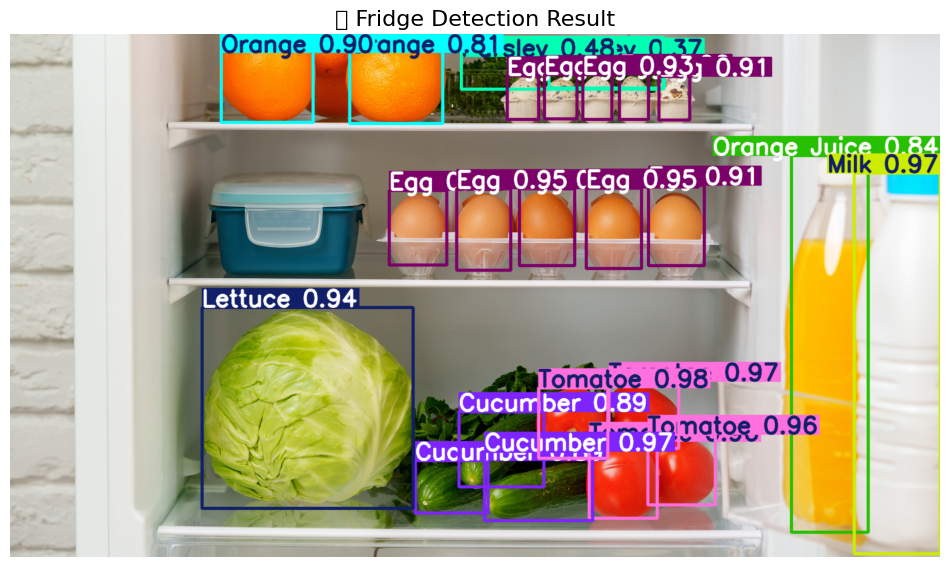

In [ ]:
import cv2
import matplotlib.pyplot as plt

result_img     = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(result_img_rgb)
plt.title('🔍 Fridge Detection Result', fontsize=16)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


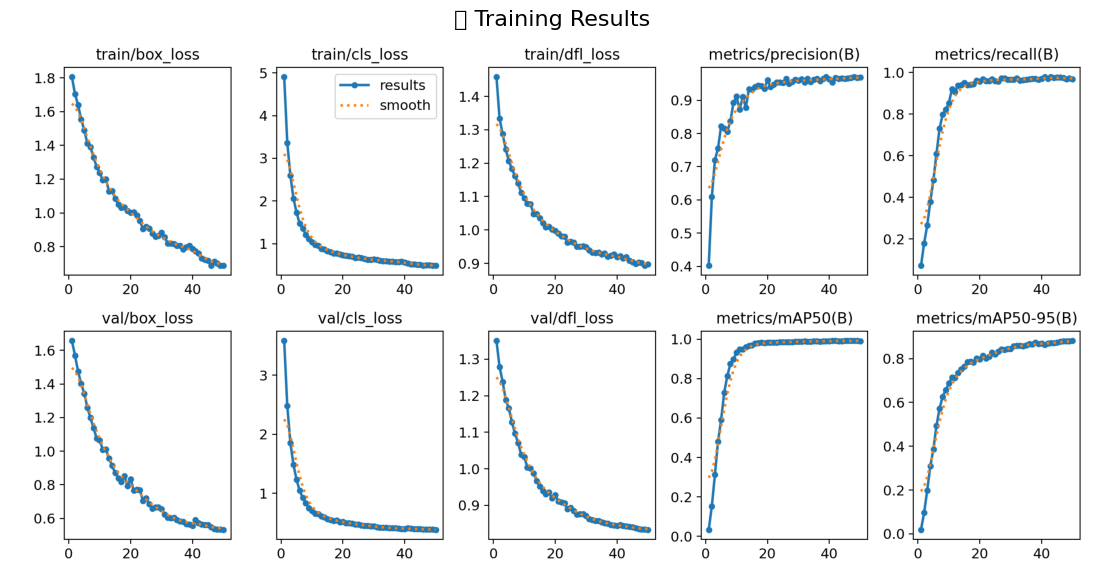

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_img = '/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/results.png'

img = mpimg.imread(results_img)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.title('📊 Training Results', fontsize=16)
plt.show()

In [ ]:
from ultralytics import YOLO
import pandas as pd

# Load your trained model
model = YOLO('/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/weights/best.pt')

# Run validation to get exact metrics
metrics = model.val(
    data='/content/drive/MyDrive/fruit_veg_detection/dataset/data.yaml',
    split='val'
)

# Print all results clearly
print('=' * 50)
print('MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'Precision:     {metrics.box.p.mean():.4f}  ({metrics.box.p.mean()*100:.2f}%)')
print(f'Recall:        {metrics.box.r.mean():.4f}  ({metrics.box.r.mean()*100:.2f}%)')
print(f'mAP50:         {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)')
print(f'mAP50-95:      {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)')
print(f'F1 Score:      {2 * metrics.box.p.mean() * metrics.box.r.mean() / (metrics.box.p.mean() + metrics.box.r.mean()):.4f}')
print('=' * 50)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,151,513 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 22.3±48.2 ms, read: 0.6±1.1 MB/s, size: 75.9 KB)
val: Scanning /content/drive/MyDrive/fruit_veg_detection/dataset/valid/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 16.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1s/it 7.5s
                   all        106       2182      0.969      0.968      0.991       0.88
                 Apple         50        158          1      0.968      0.995      0.851
           Apple Juice          3          3      0.933          1      0.995      0.951
             Asperagus          4          4      0.941          1      0.995      0.852
                Banana         23         23      0.989          1      0.995      0.914
                  

In [ ]:
model = YOLO('/content/drive/MyDrive/fruit_veg_detection/models/fridge_detection/weights/best.pt')


In [ ]:
recipes = {
    # FRUITS
    "Apple": {
        "recipes": ["🥧 Apple Pie", "🥤 Apple Smoothie", "🥗 Apple Walnut Salad",
                    "🍎 Apple Cinnamon Oatmeal", "🧃 Fresh Apple Juice"],
        "ingredients_needed": ["flour, butter, sugar", "milk, honey", "lettuce, walnuts",
                                "oats, cinnamon", "water"]
    },
    "Banana": {
        "recipes": ["🍞 Banana Bread", "🥤 Banana Smoothie", "🥞 Banana Pancakes",
                    "🍨 Banana Ice Cream", "🥣 Banana Oat Bowl"],
        "ingredients_needed": ["flour, eggs, butter", "milk, honey", "flour, eggs",
                                "cream", "oats, honey"]
    },
    "Blueberry": {
        "recipes": ["🧁 Blueberry Muffins", "🥤 Blueberry Smoothie", "🥞 Blueberry Pancakes",
                    "🍦 Blueberry Yogurt Parfait", "🫐 Blueberry Jam"],
        "ingredients_needed": ["flour, butter, sugar", "milk, yogurt", "flour, eggs",
                                "yogurt, granola", "sugar, lemon"]
    },
    "Grape": {
        "recipes": ["🍇 Grape Juice", "🥗 Grape Chicken Salad", "🍨 Frozen Grape Sorbet",
                    "🧃 Grape Smoothie", "🫙 Grape Jam"],
        "ingredients_needed": ["water, sugar", "chicken, lettuce", "sugar",
                                "yogurt, honey", "sugar, lemon"]
    },
    "Lemon": {
        "recipes": ["🍋 Lemonade", "🎂 Lemon Cake", "🍗 Lemon Garlic Chicken",
                    "🥗 Lemon Vinaigrette Salad", "🍝 Lemon Butter Pasta"],
        "ingredients_needed": ["water, sugar", "flour, butter, eggs", "garlic, olive oil",
                                "olive oil, mustard", "pasta, butter, garlic"]
    },
    "Lime": {
        "recipes": ["🍹 Lime Margarita", "🌮 Lime Chicken Tacos", "🥗 Lime Avocado Salad",
                    "🍰 Key Lime Pie", "🥤 Lime Mint Cooler"],
        "ingredients_needed": ["salt, tequila", "chicken, tortilla", "avocado, cilantro",
                                "cream, butter", "mint, water, sugar"]
    },
    "Melon": {
        "recipes": ["🍈 Melon Smoothie", "🥗 Melon Prosciutto Salad", "🍧 Melon Sorbet",
                    "🧃 Melon Mint Juice", "🥗 Melon Feta Salad"],
        "ingredients_needed": ["yogurt, honey", "prosciutto, mint", "sugar",
                                "mint, sugar", "feta, mint, olive oil"]
    },
    "Orange": {
        "recipes": ["🍊 Fresh Orange Juice", "🎂 Orange Cake", "🥗 Orange Walnut Salad",
                    "🍗 Orange Glazed Chicken", "🥤 Orange Smoothie"],
        "ingredients_needed": ["water", "flour, butter, eggs", "walnuts, lettuce",
                                "honey, soy sauce", "yogurt, honey"]
    },
    "Pear": {
        "recipes": ["🍐 Poached Pear", "🥗 Pear Gorgonzola Salad", "🧁 Pear Muffins",
                    "🥤 Pear Smoothie", "🫙 Pear Jam"],
        "ingredients_needed": ["red wine, sugar", "gorgonzola, walnuts", "flour, butter",
                                "yogurt, honey", "sugar, lemon"]
    },
    "Pineapple": {
        "recipes": ["🍍 Pineapple Juice", "🍕 Hawaiian Pizza", "🥤 Pina Colada Smoothie",
                    "🍛 Pineapple Fried Rice", "🎂 Pineapple Upside Down Cake"],
        "ingredients_needed": ["water", "pizza dough, ham", "coconut milk, yogurt",
                                "rice, soy sauce", "flour, butter, sugar"]
    },
    "Plum": {
        "recipes": ["🍮 Plum Pudding", "🫙 Plum Jam", "🥤 Plum Smoothie",
                    "🥧 Plum Tart", "🍶 Plum Sauce"],
        "ingredients_needed": ["eggs, cream", "sugar, lemon", "yogurt, honey",
                                "flour, butter", "soy sauce, ginger"]
    },
    "Raspberry": {
        "recipes": ["🥤 Raspberry Smoothie", "🎂 Raspberry Cheesecake", "🫙 Raspberry Jam",
                    "🍦 Raspberry Sorbet", "🥞 Raspberry Pancakes"],
        "ingredients_needed": ["yogurt, milk", "cream cheese, graham crackers", "sugar, lemon",
                                "sugar", "flour, eggs"]
    },
    "Strawberry": {
        "recipes": ["🍓 Strawberry Smoothie", "🎂 Strawberry Shortcake", "🫙 Strawberry Jam",
                    "🥗 Strawberry Spinach Salad", "🍨 Strawberry Ice Cream"],
        "ingredients_needed": ["yogurt, milk", "flour, cream", "sugar, lemon",
                                "spinach, almonds", "cream, sugar"]
    },
    "Watermelon": {
        "recipes": ["🍉 Watermelon Juice", "🥗 Watermelon Feta Salad", "🥤 Watermelon Smoothie",
                    "🍧 Watermelon Sorbet", "🥗 Watermelon Mint Salad"],
        "ingredients_needed": ["water", "feta, mint, olive oil", "yogurt, lime",
                                "sugar, lime", "mint, lime"]
    },
    "avocado": {
        "recipes": ["🥑 Guacamole", "🍞 Avocado Toast", "🥗 Avocado Chicken Salad",
                    "🌮 Avocado Tacos", "🥤 Avocado Smoothie"],
        "ingredients_needed": ["onion, lime, cilantro", "bread, lemon, salt", "chicken, lettuce",
                                "tortilla, lime", "milk, honey, banana"]
    },
    # VEGETABLES
    "Asperagus": {
        "recipes": ["🥘 Roasted Asparagus", "🍝 Asparagus Pasta", "🥗 Asparagus Salad",
                    "🍳 Asparagus Omelette", "🍲 Asparagus Soup"],
        "ingredients_needed": ["olive oil, garlic", "pasta, parmesan", "lemon, olive oil",
                                "eggs, cheese", "cream, onion"]
    },
    "Brocoli": {
        "recipes": ["🥦 Broccoli Stir Fry", "🧀 Broccoli Cheese Soup", "🥗 Broccoli Salad",
                    "🍝 Broccoli Pasta", "🥘 Broccoli Casserole"],
        "ingredients_needed": ["soy sauce, garlic", "cheddar, cream", "raisins, bacon",
                                "pasta, garlic, olive oil", "cream, cheddar"]
    },
    "Carrot": {
        "recipes": ["🥤 Carrot Juice", "🍮 Carrot Halwa", "🥗 Carrot Salad",
                    "🍲 Carrot Ginger Soup", "🎂 Carrot Cake"],
        "ingredients_needed": ["water, ginger", "milk, sugar, ghee", "lemon, parsley",
                                "ginger, onion, cream", "flour, eggs, cinnamon"]
    },
    "Celery": {
        "recipes": ["🥤 Celery Juice", "🍲 Celery Soup", "🥗 Waldorf Salad",
                    "🥘 Celery Stir Fry", "🧃 Green Detox Juice"],
        "ingredients_needed": ["water, lemon", "onion, cream", "apple, walnut, mayo",
                                "garlic, soy sauce", "cucumber, spinach, lemon"]
    },
    "Corn": {
        "recipes": ["🌽 Grilled Corn", "🥣 Corn Soup", "🥗 Corn Salad",
                    "🫔 Corn Tortillas", "🥘 Corn Chowder"],
        "ingredients_needed": ["butter, salt", "cream, onion", "lime, cilantro",
                                "masa, water", "potato, cream, bacon"]
    },
    "Cucumber": {
        "recipes": ["🥗 Cucumber Salad", "🥛 Tzatziki", "💧 Cucumber Detox Water",
                    "🥒 Cucumber Raita", "🥗 Greek Salad"],
        "ingredients_needed": ["vinegar, dill", "yogurt, garlic, dill", "mint, lemon",
                                "yogurt, cumin, mint", "tomato, feta, olive oil"]
    },
    "Eggplant": {
        "recipes": ["🍆 Baba Ganoush", "🍆 Eggplant Parmesan", "🍛 Baingan Bharta",
                    "🥘 Eggplant Stir Fry", "🫙 Eggplant Chutney"],
        "ingredients_needed": ["tahini, garlic, lemon", "tomato sauce, mozzarella", "onion, tomato, spices",
                                "soy sauce, garlic", "onion, vinegar, spices"]
    },
    "Garlic": {
        "recipes": ["🍞 Garlic Bread", "🍝 Aglio e Olio Pasta", "🍗 Garlic Butter Chicken",
                    "🫙 Garlic Chutney", "🥘 Garlic Roasted Vegetables"],
        "ingredients_needed": ["bread, butter", "pasta, olive oil, parsley", "butter, lemon",
                                "coconut, tamarind", "olive oil, herbs"]
    },
    "Lettuce": {
        "recipes": ["🥗 Caesar Salad", "🌯 Lettuce Wrap", "🥗 Garden Salad",
                    "🫔 BLT Sandwich", "🥗 Greek Salad"],
        "ingredients_needed": ["parmesan, croutons, dressing", "chicken, soy sauce", "tomato, cucumber",
                                "bacon, tomato, bread", "tomato, cucumber, feta"]
    },
    "Onion": {
        "recipes": ["🍲 French Onion Soup", "🧅 Caramelized Onions", "🍟 Onion Rings",
                    "🫙 Onion Chutney", "🥘 Onion Gravy"],
        "ingredients_needed": ["beef broth, bread, cheese", "butter, sugar", "flour, breadcrumbs",
                                "tamarind, spices", "butter, flour"]
    },
    "Parsley": {
        "recipes": ["🥗 Tabbouleh", "🍝 Parsley Pasta", "🫙 Chimichurri Sauce",
                    "🍲 Parsley Soup", "🥗 Parsley Salad"],
        "ingredients_needed": ["bulgur, tomato, lemon", "pasta, garlic, olive oil", "garlic, olive oil, vinegar",
                                "potato, cream", "lemon, olive oil"]
    },
    "Pepper": {
        "recipes": ["🫑 Stuffed Bell Pepper", "🥘 Pepper Stir Fry", "🍝 Pepper Pasta",
                    "🥗 Roasted Pepper Salad", "🫙 Pepper Sauce"],
        "ingredients_needed": ["rice, ground beef", "soy sauce, garlic", "pasta, olive oil",
                                "olive oil, feta", "cream, butter"]
    },
    "Pumpkin": {
        "recipes": ["🎃 Pumpkin Soup", "🥧 Pumpkin Pie", "🍛 Pumpkin Curry",
                    "🧁 Pumpkin Muffins", "🥘 Pumpkin Risotto"],
        "ingredients_needed": ["cream, onion, ginger", "cream, eggs, spices", "coconut milk, spices",
                                "flour, cinnamon, eggs", "rice, parmesan, onion"]
    },
    "Raddish": {
        "recipes": ["🥗 Radish Salad", "🥒 Pickled Radish", "🍲 Radish Soup",
                    "🥘 Radish Stir Fry", "🫙 Radish Kimchi"],
        "ingredients_needed": ["lemon, olive oil", "vinegar, sugar", "onion, cream",
                                "soy sauce, garlic", "gochugaru, garlic, ginger"]
    },
    "Spinich": {
        "recipes": ["🥤 Green Smoothie", "🍛 Palak Paneer", "🥗 Spinach Salad",
                    "🍳 Spinach Omelette", "🍝 Spinach Pasta"],
        "ingredients_needed": ["banana, apple", "paneer, cream, spices", "strawberry, almonds",
                                "eggs, cheese", "pasta, garlic, cream"]
    },
    "Squash": {
        "recipes": ["🍲 Butternut Squash Soup", "🥘 Squash Risotto", "🫔 Squash Quesadilla",
                    "🥗 Roasted Squash Salad", "🍛 Squash Curry"],
        "ingredients_needed": ["cream, onion, ginger", "rice, parmesan", "cheese, tortilla",
                                "arugula, feta", "coconut milk, spices"]
    },
    "Tomatoe": {
        "recipes": ["🍲 Tomato Soup", "🍝 Tomato Pasta", "🥗 Caprese Salad",
                    "🫙 Tomato Sauce", "🥘 Shakshuka"],
        "ingredients_needed": ["cream, onion", "pasta, garlic, basil", "mozzarella, basil, olive oil",
                                "garlic, basil, olive oil", "eggs, onion, spices"]
    },
    "Zucchini": {
        "recipes": ["🥘 Zucchini Fritters", "🍝 Zucchini Pasta", "🥗 Zucchini Salad",
                    "🧁 Zucchini Bread", "🥘 Ratatouille"],
        "ingredients_needed": ["flour, eggs", "pasta, garlic, olive oil", "lemon, feta",
                                "flour, eggs, cinnamon", "tomato, eggplant, pepper"]
    },
    "cabbage": {
        "recipes": ["🥗 Coleslaw", "🥘 Stuffed Cabbage Rolls", "🍲 Cabbage Soup",
                    "🥘 Cabbage Stir Fry", "🫙 Sauerkraut"],
        "ingredients_needed": ["mayo, vinegar", "rice, ground beef", "carrot, onion, broth",
                                "soy sauce, garlic", "salt, caraway"]
    },
    "eggplant": {
        "recipes": ["🍆 Baba Ganoush", "🍆 Eggplant Parmesan", "🍛 Baingan Bharta",
                    "🥘 Eggplant Stir Fry", "🫙 Eggplant Chutney"],
        "ingredients_needed": ["tahini, garlic, lemon", "tomato sauce, mozzarella", "onion, tomato, spices",
                                "soy sauce, garlic", "onion, vinegar, spices"]
    },
    "pea": {
        "recipes": ["🍲 Pea Soup", "🍛 Matar Paneer", "🥗 Pea Salad",
                    "🍝 Pasta e Piselli", "🥘 Pea Risotto"],
        "ingredients_needed": ["cream, onion, mint", "paneer, cream, spices", "mint, feta",
                                "pasta, parmesan", "rice, parmesan, onion"]
    },
    "potatoe": {
        "recipes": ["🥔 Mashed Potato", "🍟 French Fries", "🍲 Potato Soup",
                    "🥘 Aloo Paratha", "🥗 Potato Salad"],
        "ingredients_needed": ["butter, cream, milk", "oil, salt", "cream, onion, bacon",
                                "flour, spices", "mayo, mustard, onion"]
    },
    "salad dressing": {
        "recipes": ["🥗 Classic Caesar Salad", "🥗 Garden Salad", "🥗 Greek Salad",
                    "🥗 Cobb Salad", "🥗 Nicoise Salad"],
        "ingredients_needed": ["romaine, croutons, parmesan", "lettuce, tomato, cucumber",
                                "feta, olive, cucumber", "chicken, egg, bacon", "tuna, egg, olive"]
    },
    # DAIRY & PROTEINS
    "Cheese": {
        "recipes": ["🧀 Grilled Cheese Sandwich", "🍝 Mac and Cheese", "🍕 Cheese Pizza",
                    "🧀 Cheese Omelette", "🫕 Cheese Fondue"],
        "ingredients_needed": ["bread, butter", "pasta, milk, butter", "pizza dough, tomato sauce",
                                "eggs, butter", "bread, white wine, garlic"]
    },
    "Egg": {
        "recipes": ["🍳 Scrambled Eggs", "🥚 Boiled Eggs", "🍳 Omelette",
                    "🍚 Egg Fried Rice", "🥘 Shakshuka"],
        "ingredients_needed": ["butter, salt", "water, salt", "cheese, vegetables",
                                "rice, soy sauce, vegetables", "tomato, onion, spices"]
    },
    "Feta": {
        "recipes": ["🥗 Greek Salad", "🧀 Feta Stuffed Peppers", "🥗 Watermelon Feta Salad",
                    "🍕 Feta Pizza", "🥗 Spinach Feta Salad"],
        "ingredients_needed": ["tomato, olive, cucumber", "peppers, olive oil", "watermelon, mint",
                                "pizza dough, olives", "spinach, olive oil"]
    },
    "Milk": {
        "recipes": ["🥛 Milkshake", "🥣 Porridge", "☕ Hot Chocolate",
                    "🥞 Pancakes", "🍮 Custard"],
        "ingredients_needed": ["ice cream, vanilla", "oats, honey", "cocoa, sugar",
                                "flour, eggs, butter", "eggs, sugar, vanilla"]
    },
    "Yogurt": {
        "recipes": ["🫐 Yogurt Parfait", "🥤 Mango Lassi", "🥒 Tzatziki",
                    "🥗 Yogurt Salad Dressing", "🍦 Frozen Yogurt"],
        "ingredients_needed": ["granola, berries", "mango, sugar", "cucumber, garlic, dill",
                                "lemon, herbs", "sugar, vanilla"]
    },
    "Chicken": {
        "recipes": ["🍛 Chicken Curry", "🍗 Grilled Chicken", "🍲 Chicken Soup",
                    "🌮 Chicken Tacos", "🍝 Chicken Pasta"],
        "ingredients_needed": ["onion, tomato, spices", "olive oil, herbs", "vegetables, broth",
                                "tortilla, salsa, lettuce", "pasta, cream, garlic"]
    },
    "Beef": {
        "recipes": ["🍲 Beef Stew", "🍔 Beef Burger", "🥘 Beef Stir Fry",
                    "🌮 Beef Tacos", "🍝 Bolognese Pasta"],
        "ingredients_needed": ["potato, carrot, broth", "bun, lettuce, tomato", "soy sauce, vegetables",
                                "tortilla, salsa", "pasta, tomato, wine"]
    },
    "Sausage": {
        "recipes": ["🌭 Sausage Roll", "🍳 Sausage and Eggs", "🥘 Sausage Stew",
                    "🍕 Sausage Pizza", "🥘 Sausage Pasta"],
        "ingredients_needed": ["pastry, mustard", "eggs, toast", "potato, onion, broth",
                                "pizza dough, tomato", "pasta, tomato, onion"]
    },
    # CONDIMENTS & OTHERS
    "Ketchup": {
        "recipes": ["🍟 Ketchup Dipping Sauce", "🍔 Burger Sauce", "🥘 Tomato Gravy",
                    "🌭 Hot Dog Topping", "🍕 Pizza Sauce Alternative"],
        "ingredients_needed": ["mayo, mustard", "mayo, pickles", "onion, spices",
                                "mustard, relish", "garlic, herbs"]
    },
    "Mustard": {
        "recipes": ["🥗 Honey Mustard Dressing", "🍔 Mustard Burger", "🍗 Mustard Chicken",
                    "🥙 Mustard Wrap", "🫙 Mustard Sauce"],
        "ingredients_needed": ["honey, vinegar", "beef patty, bun", "chicken, honey",
                                "lettuce, turkey", "cream, herbs"]
    },
    "Olive": {
        "recipes": ["🥗 Olive Tapenade", "🍕 Olive Pizza", "🥗 Greek Salad",
                    "🍝 Puttanesca Pasta", "🫙 Marinated Olives"],
        "ingredients_needed": ["capers, garlic, lemon", "pizza dough, feta", "feta, tomato, cucumber",
                                "pasta, capers, anchovies", "herbs, garlic, olive oil"]
    },
    "Olive Oil": {
        "recipes": ["🫙 Herb Infused Oil", "🥗 Simple Vinaigrette", "🍞 Olive Oil Dip",
                    "🍝 Aglio e Olio", "🥘 Roasted Vegetables"],
        "ingredients_needed": ["rosemary, thyme", "vinegar, mustard", "bread, herbs",
                                "pasta, garlic, parsley", "vegetables, herbs"]
    },
    "Hot Sauce": {
        "recipes": ["🌶️ Spicy Wings", "🌮 Spicy Tacos", "🥘 Hot Sauce Stir Fry",
                    "🍳 Spicy Shakshuka", "🥗 Spicy Salad Dressing"],
        "ingredients_needed": ["chicken, butter", "tortilla, chicken", "vegetables, soy sauce",
                                "eggs, tomato", "vinegar, honey"]
    },
    "Vinegar": {
        "recipes": ["🥗 Vinaigrette Dressing", "🫙 Pickled Vegetables", "🍲 Sweet and Sour",
                    "🥒 Quick Pickles", "🍗 Vinegar Chicken"],
        "ingredients_needed": ["olive oil, mustard", "vegetables, sugar", "sugar, soy sauce",
                                "cucumber, dill", "garlic, herbs"]
    },
    "soya sauce": {
        "recipes": ["🥘 Soy Glazed Chicken", "🍚 Fried Rice", "🥢 Stir Fry Vegetables",
                    "🍜 Ramen Broth", "🥡 Teriyaki Salmon"],
        "ingredients_needed": ["chicken, garlic, ginger", "rice, eggs, vegetables", "garlic, ginger",
                                "broth, mirin", "salmon, mirin, sugar"]
    },
    # BEVERAGES
    "Apple Juice": {
        "recipes": ["🥤 Apple Ginger Mocktail", "🥘 Apple Glazed Pork", "🍮 Apple Jelly",
                    "🥤 Apple Cider Punch", "🍲 Apple Braised Chicken"],
        "ingredients_needed": ["ginger, lemon", "pork, cinnamon", "gelatin, sugar",
                                "cinnamon, cloves", "chicken, onion, cinnamon"]
    },
    "Orange Juice": {
        "recipes": ["🥤 Orange Sunrise Mocktail", "🍊 Orange Glazed Salmon", "🥞 OJ Pancakes",
                    "🍰 Orange Jelly Cake", "🥤 Citrus Punch"],
        "ingredients_needed": ["grenadine, soda", "salmon, honey", "flour, eggs",
                                "gelatin, cream", "lemon, lime, soda"]
    },
    "Milk": {
        "recipes": ["🥛 Classic Milkshake", "☕ Café Latte", "🥣 Overnight Oats",
                    "🍮 Panna Cotta", "🥞 Milk Pancakes"],
        "ingredients_needed": ["ice cream, vanilla", "espresso", "oats, chia seeds",
                                "cream, gelatin, vanilla", "flour, eggs, butter"]
    },
    "Coconut Water": {
        "recipes": ["🥥 Coconut Water Smoothie", "🍹 Coconut Mocktail", "🥘 Coconut Rice",
                    "🤒 Electrolyte Drink", "🥤 Tropical Punch"],
        "ingredients_needed": ["mango, pineapple", "lime, mint", "rice, pandan",
                                "lemon, honey, salt", "pineapple, lime"]
    },
    "Coffee Cream": {
        "recipes": ["☕ Whipped Coffee", "🍰 Coffee Cake", "🍨 Coffee Ice Cream",
                    "☕ Café Mocha", "🍮 Coffee Panna Cotta"],
        "ingredients_needed": ["instant coffee, sugar, water", "flour, butter, sugar", "eggs, sugar",
                                "cocoa, milk, sugar", "gelatin, vanilla"]
    },
    "Beer": {
        "recipes": ["🍺 Beer Battered Fish", "🥘 Beer Braised Beef", "🍞 Beer Bread",
                    "🥘 Beer Cheese Soup", "🍗 Beer Can Chicken"],
        "ingredients_needed": ["fish, flour, oil", "beef, onion, broth", "flour, baking powder",
                                "cheddar, cream, onion", "chicken, spices"]
    },
    "Coke": {
        "recipes": ["🍗 Cola Chicken", "🥩 Cola Glazed Ribs", "🍺 Coke Float",
                    "🥘 Cola BBQ Sauce", "🍰 Coke Cake"],
        "ingredients_needed": ["chicken, soy sauce", "ribs, BBQ sauce", "vanilla ice cream",
                                "ketchup, mustard", "flour, cocoa, butter"]
    },
    "Bubbly Water": {
        "recipes": ["🍋 Sparkling Lemonade", "🥤 Fruit Spritzer", "🍹 Virgin Mojito",
                    "🥤 Elderflower Fizz", "🥤 Cucumber Mint Spritzer"],
        "ingredients_needed": ["lemon, sugar", "fruit juice, mint", "lime, mint, sugar",
                                "elderflower syrup, lemon", "cucumber, mint, lime"]
    },
    "Water": {
        "recipes": ["💧 Infused Detox Water", "🍵 Herbal Tea", "💧 Lemon Water",
                    "💧 Cucumber Mint Water", "💧 Ginger Water"],
        "ingredients_needed": ["lemon, cucumber, mint", "herbs, honey", "lemon, honey",
                                "cucumber, mint", "ginger, lemon, honey"]

    },
    "Normal Orange Juice": {
        "recipes": ["Orange Jucie"],
        "ingredients_needed": ["Orange"]
        },

    # OTHERS
    "Ice Cream": {
        "recipes": ["🍨 Ice Cream Sundae", "🥤 Milkshake", "🍰 Ice Cream Cake",
                    "🥞 Ice Cream Waffle", "🍦 Affogato"],
        "ingredients_needed": ["toppings, syrup", "milk, vanilla", "cake layers, cream",
                                "waffle, toppings", "espresso"]
    },
    "Pickle": {
        "recipes": ["🥗 Pickle Relish", "🍔 Burger with Pickles", "🥗 Pickle Salad",
                    "🫙 Pickle Brine Chicken", "🌭 Pickle Dog"],
        "ingredients_needed": ["onion, mustard", "beef patty, bun", "dill, onion",
                                "chicken, garlic", "sausage, mustard, bun"]
    },
    "Tortilla": {
        "recipes": ["🌮 Tacos", "🌯 Burrito", "🫔 Quesadilla",
                    "🥙 Wrap", "🍕 Tortilla Pizza"],
        "ingredients_needed": ["chicken, salsa, lettuce", "rice, beans, cheese", "cheese, chicken, peppers",
                                "turkey, lettuce, mayo", "tomato sauce, mozzarella"]
    },
    "Peanuts": {
        "recipes": ["🥜 Peanut Butter", "🍜 Peanut Noodles", "🥗 Peanut Salad",
                    "🍡 Peanut Brittle", "🥘 Peanut Stew"],
        "ingredients_needed": ["salt, oil", "noodles, soy sauce, ginger", "cabbage, lime, cilantro",
                                "sugar, corn syrup", "sweet potato, tomato, spices"]
    },
    "Sour Cream": {
        "recipes": ["🌮 Sour Cream Tacos", "🥔 Baked Potato Topping", "🎂 Sour Cream Cake",
                    "🥗 Sour Cream Dressing", "🫕 Stroganoff"],
        "ingredients_needed": ["tortilla, chicken", "potato, chives, cheese", "flour, eggs, butter",
                                "herbs, lemon", "beef, pasta, mushroom"]
    },
}


In [ ]:
from google.colab import files

print('Upload a fridge image to test...')
uploaded = files.upload()
test_image = list(uploaded.keys())[0]
print(f'✅ Uploaded: {test_image}')

Upload a fridge image to test...


Saving fridgee.jpg to fridgee.jpg
✅ Uploaded: fridgee.jpg


In [ ]:
# Run detection
results = model.predict(
    source=test_image,
    conf=0.25,
    save=True,
    show_labels=True,
    show_conf=True
)

# Get detected items
detected_items = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        detected_items.append(class_name)
        print(f'  🔍 Detected: {class_name} ({confidence:.0%} confidence)')

print(f'\n✅ Total items detected: {len(detected_items)}')
print(f'Items: {list(set(detected_items))}')


image 1/1 /content/fridgee.jpg: 448x640 4 Apples, 3 Carrots, 4 Cucumbers, 6 Eggs, 2 Lemons, 2 Milks, 5 Peppers, 1 Pineapple, 4 Tomatoes, 3 Waters, 15.9ms
Speed: 5.2ms preprocess, 15.9ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
  🔍 Detected: Carrot (98% confidence)
  🔍 Detected: Water (97% confidence)
  🔍 Detected: Lemon (96% confidence)
  🔍 Detected: Carrot (95% confidence)
  🔍 Detected: Milk (95% confidence)
  🔍 Detected: Lemon (94% confidence)
  🔍 Detected: Cucumber (94% confidence)
  🔍 Detected: Pepper (94% confidence)
  🔍 Detected: Apple (93% confidence)
  🔍 Detected: Pepper (91% confidence)
  🔍 Detected: Pepper (91% confidence)
  🔍 Detected: Pepper (90% confidence)
  🔍 Detected: Pepper (89% confidence)
  🔍 Detected: Milk (89% confidence)
  🔍 Detected: Egg (89% confidence)
  🔍 Detected: Pineapple (88% confidence)
  🔍 Detected: Water (88% confidence)
  🔍 Detected: Apple (88% confidence)
  🔍 Detected: Egg (83% con

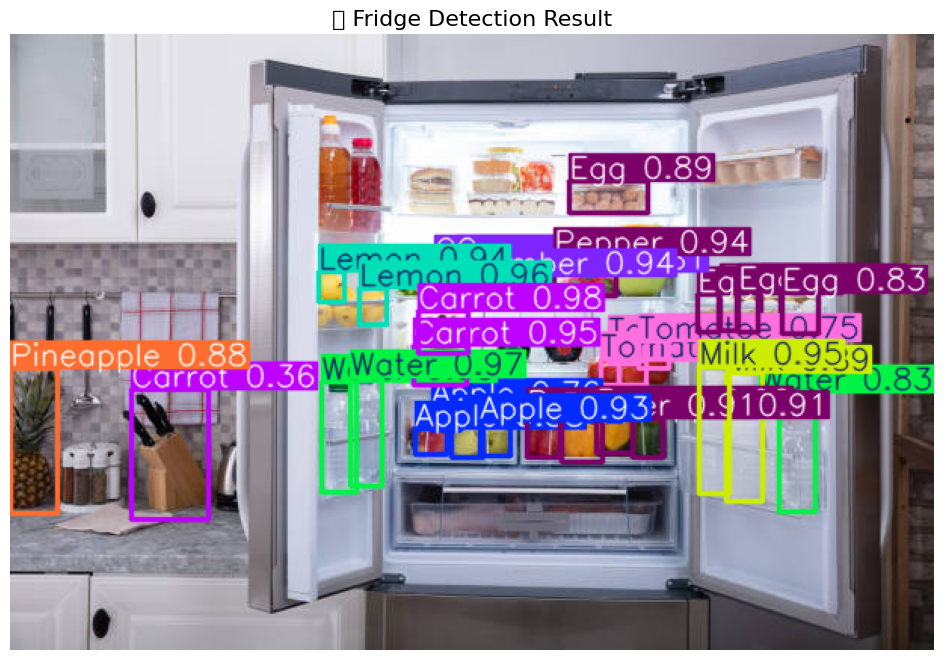

In [ ]:
import cv2
import matplotlib.pyplot as plt

result_img     = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_img_rgb)
plt.title('🔍 Fridge Detection Result', fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
def get_recipes(detected_items):
    matched = {}
    for item in detected_items:
        for key in recipes:
            if key.lower() in item.lower() or item.lower() in key.lower():
                matched[item] = recipes[key]
                break
    return matched

def detect_and_recommend(image, confidence):
    if image is None:
        return None, "Please upload a fridge image!"

    img_array = np.array(image)
    results   = model.predict(source=img_array, conf=confidence, save=False)

    # Collect detected items
    detected_items = []
    for result in results:
        for box in result.boxes:
            class_id   = int(box.cls[0])
            class_name = model.names[class_id]
            conf_score = float(box.conf[0])
            detected_items.append((class_name, conf_score))

    # Draw bounding boxes
    result_img     = results[0].plot()
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # No items detected
    if len(detected_items) == 0:
        output = (
            " NO ITEMS DETECTED\n\n"
            "Tips:\n"
            "  • Try a clearer fridge image\n"
            "  • Lower the confidence slider\n"
            "  • Make sure items are visible"
        )
        return Image.fromarray(result_img_rgb), output

    # Get unique items with confidence
    seen        = set()
    unique_items = []
    for name, conf in detected_items:
        if name not in seen:
            seen.add(name)
            unique_items.append((name, conf))

    # Match recipes
    matched = get_recipes([name for name, _ in unique_items])

    # Build clean output
    lines = []

    # ── DETECTED ITEMS ──────────────────────────────────
    lines.append("🧊  FRIDGE DETECTIVE RESULTS")
    lines.append("")
    lines.append("🛒  ITEMS FOUND IN YOUR FRIDGE")
    lines.append("")

    for idx, (name, conf) in enumerate(unique_items, 1):
        lines.append(f"   {idx}.  {name}  —  {conf:.0%} confidence")

    lines.append("")
    lines.append(f"   Total items detected :  {len(unique_items)}")
    lines.append(f"   Recipe matches found :  {len(matched)}")

    # ── RECIPES PER ITEM ────────────────────────────────
    lines.append("")
    lines.append("")
    lines.append("🍽️  RECIPE RECOMMENDATIONS")
    lines.append("")

    if not matched:
        lines.append("   No recipes found for detected items.")
        lines.append("   Try uploading a clearer fridge image.")
    else:
        for item, info in matched.items():
            lines.append(f"   🥘  {item.upper()}")
            lines.append("")
            for i, recipe in enumerate(info["recipes"]):
                needed = info["ingredients_needed"][i]
                lines.append(f"      {i + 1}.  {recipe}")
                lines.append(f"            📌 Also need :  {needed}")
                lines.append("")
            lines.append("")

    # ── MULTI INGREDIENT COMBOS ─────────────────────────
    if len(matched) > 1:
        combos = {
            frozenset(["Apple",   "Banana"])        : "🥤 Mixed Fruit Smoothie",
            frozenset(["Egg",     "Milk"])           : "🍳 French Toast",
            frozenset(["Egg",     "Cheese"])         : "🧀 Cheese Omelette",
            frozenset(["Tomato",  "Cheese"])         : "🍕 Pizza Toast",
            frozenset(["Chicken", "Garlic"])         : "🍗 Garlic Butter Chicken",
            frozenset(["Spinach", "Egg"])            : "🥬 Spinach Egg Scramble",
            frozenset(["Banana",  "Milk"])           : "🥛 Banana Milkshake",
            frozenset(["Milk",    "Yogurt"])         : "🥤 Creamy Smoothie Bowl",
            frozenset(["Lemon",   "Garlic"])         : "🍋 Lemon Garlic Dressing",
            frozenset(["Tomato",  "Onion"])          : "🍅 Fresh Tomato Salsa",
            frozenset(["Cucumber","Yogurt"])         : "🥒 Tzatziki Dip",
            frozenset(["Milk",    "Egg"])            : "🍮 Custard",
            frozenset(["Strawberry","Milk"])         : "🍓 Strawberry Milkshake",
            frozenset(["Pineapple","Coconut Water"]) : "🍹 Tropical Punch",
            frozenset(["Avocado", "Lemon"])          : "🥑 Guacamole",
            frozenset(["Pepper",  "Onion"])          : "🫑 Sauteed Pepper and Onion",
            frozenset(["Beef",    "Onion"])          : "🍔 Classic Beef Burger",
            frozenset(["Chicken", "Lemon"])          : "🍗 Lemon Herb Chicken",
            frozenset(["Carrot",  "Ginger"])         : "🥕 Carrot Ginger Soup",
            frozenset(["Apple",   "Yogurt"])         : "🥣 Apple Yogurt Bowl",
            frozenset(["Banana",  "Yogurt"])         : "🍌 Banana Yogurt Smoothie",
            frozenset(["Milk",    "Banana"])         : "🥛 Banana Milkshake",
            frozenset(["Egg",     "Butter"])         : "🍳 Buttered Scrambled Eggs",
            frozenset(["Cheese",  "Tomato"])         : "🧀 Caprese Toast",
        }

        detected_set  = set(n.lower() for n in matched.keys())
        found_combos  = []

        for key_set, combo_recipe in combos.items():
            if all(k.lower() in detected_set for k in key_set):
                ingredients = "  +  ".join(key_set)
                found_combos.append((combo_recipe, ingredients))

        if found_combos:
            lines.append("🌟  BONUS  —  MULTI-INGREDIENT RECIPES")
            lines.append("")
            lines.append("   You can also combine detected items to make:")
            lines.append("")
            for i, (recipe, ingredients) in enumerate(found_combos, 1):
                lines.append(f"   {i}.  {recipe}")
                lines.append(f"         Using :  {ingredients}")
                lines.append("")

    return Image.fromarray(result_img_rgb), "\n".join(lines)

In [ ]:
# Recipes Recommended from the image...

In [ ]:
detect_and_recommend(result_img_rgb, 0.49)


0: 448x640 2 Milks, 1 Yogurt, 12.9ms
Speed: 3.4ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


(<PIL.Image.Image image mode=RGB size=612x408>,
 '🧊  FRIDGE DETECTIVE RESULTS\n\n🛒  ITEMS FOUND IN YOUR FRIDGE\n\n   1.  Milk  —  73% confidence\n   2.  Yogurt  —  53% confidence\n\n   Total items detected :  2\n   Recipe matches found :  2\n\n\n🍽️  RECIPE RECOMMENDATIONS\n\n   🥘  MILK\n\n      1.  🥛 Classic Milkshake\n            📌 Also need :  ice cream, vanilla\n\n      2.  ☕ Café Latte\n            📌 Also need :  espresso\n\n      3.  🥣 Overnight Oats\n            📌 Also need :  oats, chia seeds\n\n      4.  🍮 Panna Cotta\n            📌 Also need :  cream, gelatin, vanilla\n\n      5.  🥞 Milk Pancakes\n            📌 Also need :  flour, eggs, butter\n\n\n   🥘  YOGURT\n\n      1.  🫐 Yogurt Parfait\n            📌 Also need :  granola, berries\n\n      2.  🥤 Mango Lassi\n            📌 Also need :  mango, sugar\n\n      3.  🥒 Tzatziki\n            📌 Also need :  cucumber, garlic, dill\n\n      4.  🥗 Yogurt Salad Dressing\n            📌 Also need :  lemon, herbs\n\n      5.  🍦 Frozen Yog